In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

from Basilisk import __path__
from Basilisk.architecture import messaging
from Basilisk.simulation import spacecraft
from Basilisk.simulation import extForceTorque
from Basilisk.simulation import simpleNav
from Basilisk.utilities import SimulationBaseClass
from Basilisk.utilities import macros
from Basilisk.utilities import unitTestSupport
from Basilisk.utilities import simIncludeGravBody

bskPath = __path__[0]

In [3]:
def run(show_plots=True):
    """
    Main simulation function for LEO to GEO low thrust transfer with circularization burn
    
    Args:
        show_plots (bool): Whether to display plots at the end
    """
    
    # --- Constants (matching reference simulation) ---
    R_E = 6378.0  # km, Earth radius
    mu = 3.986e5  # km^3/s^2, Earth gravitational parameter
    
    # Initial orbit parameters
    a_init = 622.0  # km, altitude
    r_init = a_init + R_E  # km, orbital radius
    v_init = np.sqrt(mu / r_init)  # km/s, circular orbit velocity
    
    # Final orbit parameters
    a_final = 35622.0  # km, altitude (matching reference)
    r_final = a_final + R_E  # km
    
    # Spacecraft parameters
    m_0 = 300.0  # kg, initial mass
    
    # Engine parameters (matching reference)
    T = 100 / 1000.0  # kN (1 N converted to kN)
    I_sp = 3100.0  # s, specific impulse
    g_0 = 9.807e-3  # km/s^2, standard gravity
    
    print("=" * 60)
    print("LEO to GEO Low Thrust Transfer - Basilisk Implementation")
    print("=" * 60)
    print(f"Initial Altitude: {a_init} km")
    print(f"Final Target Altitude: {a_final} km")
    print(f"Max Thrust: {T*1000} N")
    print(f"Specific Impulse: {I_sp} s")
    print(f"Initial Mass: {m_0} kg")
    print(f"Initial Speed: {v_init:.3f} km/s")
    print("=" * 60)
    
    # --- Simulation Parameters ---
    dynTaskName = "dynTask"
    dynProcessName = "dynProcess"
    
    # Create simulation
    scSim = SimulationBaseClass.SimBaseClass()
    
    # Create process and task
    dynProcess = scSim.CreateNewProcess(dynProcessName)
    simTimeStep = macros.sec2nano(100.0)  # 1 second time steps for accuracy
    dynProcess.addTask(scSim.CreateNewTask(dynTaskName, simTimeStep))
    
    # --- Spacecraft Setup ---
    scObject = spacecraft.Spacecraft()
    scObject.ModelTag = "LEO-GEO-Spacecraft"
    
    # Mass properties
    I = [900., 0., 0.,
         0., 800., 0.,
         0., 0., 600.]
    scObject.hub.mHub = m_0
    scObject.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObject.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
    
    # Initial conditions - circular LEO orbit in XY plane
    # Convert km to meters for Basilisk
    scObject.hub.r_CN_NInit = [[r_init * 1000.0], [0.0], [0.0]]  # m
    scObject.hub.v_CN_NInit = [[0.0], [v_init * 1000.0], [0.0]]  # m/s
    scObject.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObject.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]  # rad/s
    
    scSim.AddModelToTask(dynTaskName, scObject)
    
    # --- Gravity Setup ---
    # Use gravity factory to set up Earth gravity with exact mu
    gravFactory = simIncludeGravBody.gravBodyFactory()
    earth = gravFactory.createEarth()
    earth.isCentralBody = True
    earth.mu = mu * 1e9  # Convert km^3/s^2 to m^3/s^2 for exact match
    gravFactory.addBodiesTo(scObject)
    
    # --- External Force for Tangential Thrust ---
    extFTObject = extForceTorque.ExtForceTorque()
    extFTObject.ModelTag = "tangentialThrust"
    scObject.addDynamicEffector(extFTObject)
    scSim.AddModelToTask(dynTaskName, extFTObject)
    
    # --- Navigation ---
    sNavObject = simpleNav.SimpleNav()
    sNavObject.ModelTag = "SimpleNavigation"
    scSim.AddModelToTask(dynTaskName, sNavObject)
    sNavObject.scStateInMsg.subscribeTo(scObject.scStateOutMsg)
    
    # --- Data Logging ---
    samplingTime = macros.sec2nano(60.0)  # Log every 60 seconds
    scStateLog = scObject.scStateOutMsg.recorder(samplingTime)
    scSim.AddModelToTask(dynTaskName, scStateLog)
    
    # --- Initialize Simulation ---
    scSim.InitializeSimulation()
    
    # --- THRUST PHASE ---
    print("\nStarting Thrust Phase...")
    
    # Define safe time limit (stay well below overflow at ~104 days)
    SAFE_TIME_LIMIT = macros.day2nano(90.0)  # 90 days per segment
    max_simulation_time = macros.day2nano(500.0)  # 500 days total max
    update_interval = macros.sec2nano(10.0)  # Update thrust every 10 seconds
    
    thrust_phase_complete = False
    orbit_count = 0
    last_y = 0.0
    
    # Storage for detailed trajectory
    thrust_positions = []
    thrust_velocities = []
    thrust_times = []
    thrust_masses = []
    
    # Track total elapsed time across all segments
    total_elapsed_time = 0.0  # in seconds
    segment_count = 0
    
    # Initial state
    current_scObject = scObject
    current_scSim = scSim
    current_extFTObject = extFTObject
    
    while total_elapsed_time < (max_simulation_time * macros.NANO2SEC) and not thrust_phase_complete:
        segment_count += 1
        print(f"\n--- Thrust Segment {segment_count} ---")
        
        # Run this segment up to safe time limit
        segment_start_time = 0
        segment_max_time = SAFE_TIME_LIMIT
        current_time = 0
        
        while current_time < segment_max_time and not thrust_phase_complete:
            # Execute simulation step
            current_scSim.ConfigureStopTime(current_time + update_interval)
            current_scSim.ExecuteSimulation()
            
            # Get current state (in meters and m/s)
            r_BN_N = current_scObject.dynManager.getStateObject("hubPosition").getState()
            v_BN_N = current_scObject.dynManager.getStateObject("hubVelocity").getState()
            current_mass = current_scObject.hub.mHub
            
            # Convert to km and km/s for calculations
            r_vec = np.array([r_BN_N[0][0], r_BN_N[1][0], r_BN_N[2][0]]) / 1000.0
            v_vec = np.array([v_BN_N[0][0], v_BN_N[1][0], v_BN_N[2][0]]) / 1000.0
            
            r_mag = np.linalg.norm(r_vec)
            v_mag = np.linalg.norm(v_vec)
            
            # Store trajectory data (with absolute time)
            thrust_positions.append(r_vec.copy())
            thrust_velocities.append(v_vec.copy())
            thrust_times.append(total_elapsed_time + current_time * macros.NANO2SEC)
            thrust_masses.append(current_mass)
            
            # Check for orbit crossing (Y coordinate sign change)
            current_y = r_vec[1]
            if last_y < 0 and current_y >= 0 and len(thrust_times) > 1:
                orbit_count += 1
            last_y = current_y
            
            # Check if reached destination
            # We need to account for the fact that after thrust cutoff, the spacecraft will coast to apogee
            # Stop thrusting when apogee will be near target altitude
            # Estimate apogee from current orbital elements
            v_mag = np.linalg.norm(v_vec)
            v_escape = np.sqrt(2.0 * mu / r_mag)
            
            # Calculate current orbital energy and angular momentum
            specific_energy = v_mag**2 / 2.0 - mu / r_mag
            h_vec = np.cross(r_vec, v_vec)
            h_mag = np.linalg.norm(h_vec)
            
            # Calculate eccentricity
            e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r_mag
            e_mag = np.linalg.norm(e_vec)
            
            # Calculate apogee
            if specific_energy < 0:  # Bound orbit
                a_current = -mu / (2.0 * specific_energy)
                r_apo_estimate = a_current * (1.0 + e_mag)
            else:
                r_apo_estimate = r_mag
            
            # Stop thrusting when estimated apogee reaches target
            # Use 98% to have a small margin but get close to target
            if r_apo_estimate >= 0.98 * r_final:
                thrust_phase_complete = True
                print(f"Thrust Phase Complete!")
                print(f"Reached estimated apogee at target: {(total_elapsed_time + current_time * macros.NANO2SEC) / 86400.0:.4f} days")
                print(f"Current radius: {r_mag:.2f} km (altitude: {r_mag - R_E:.2f} km)")
                print(f"Current velocity: {v_mag:.3f} km/s")
                print(f"Estimated apogee: {r_apo_estimate:.2f} km (altitude: {r_apo_estimate - R_E:.2f} km)")
                print(f"Circular velocity at current radius: {np.sqrt(mu/r_mag):.3f} km/s")
                break
            
            # Calculate tangential thrust force (in velocity direction)
            if v_mag > 0:
                # Thrust direction is velocity direction (tangential)
                thrust_dir = v_vec / v_mag
                # Thrust magnitude in Newtons
                thrust_force_kN = T * thrust_dir  # kN
                # Convert to Newtons for Basilisk
                thrust_force_N = thrust_force_kN * 1000.0  # N
                
                # Apply thrust in inertial frame
                current_extFTObject.extForce_N = [
                    [thrust_force_N[0]],
                    [thrust_force_N[1]],
                    [thrust_force_N[2]]
                ]
            else:
                current_extFTObject.extForce_N = [[0.0], [0.0], [0.0]]
            
            # Update mass (fuel consumption): dm/dt = -T / (I_sp * g_0)
            dt = update_interval * macros.NANO2SEC  # seconds
            dm = -T / (I_sp * g_0) * dt  # kg (T in kN, result in kg)
            current_scObject.hub.mHub = max(10.0, current_mass + dm)  # Minimum 10 kg
            
            current_time += update_interval
        
        # Update total elapsed time
        total_elapsed_time += current_time * macros.NANO2SEC
        
        # If not complete, create new simulation for next segment
        if not thrust_phase_complete and total_elapsed_time < (max_simulation_time * macros.NANO2SEC):
            print(f"Segment time limit reached. Creating new simulation segment...")
            print(f"Progress: {(r_mag - r_init) / (r_final - r_init) * 100:.1f}% to target")
            
            # Save current state
            r_BN_N_seg = current_scObject.dynManager.getStateObject("hubPosition").getState()
            v_BN_N_seg = current_scObject.dynManager.getStateObject("hubVelocity").getState()
            current_mass_seg = current_scObject.hub.mHub
            
            # Create new simulation
            current_scSim = SimulationBaseClass.SimBaseClass()
            dynProcess_new = current_scSim.CreateNewProcess(dynProcessName + f"_{segment_count}")
            dynProcess_new.addTask(current_scSim.CreateNewTask(dynTaskName + f"_{segment_count}", simTimeStep))
            
            # Create new spacecraft
            current_scObject = spacecraft.Spacecraft()
            current_scObject.ModelTag = f"LEO-GEO-Spacecraft-Seg{segment_count}"
            current_scObject.hub.mHub = current_mass_seg
            current_scObject.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
            current_scObject.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
            current_scObject.hub.r_CN_NInit = r_BN_N_seg
            current_scObject.hub.v_CN_NInit = v_BN_N_seg
            current_scObject.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
            current_scObject.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
            
            current_scSim.AddModelToTask(dynTaskName + f"_{segment_count}", current_scObject)
            
            # Add gravity
            gravFactory_new = simIncludeGravBody.gravBodyFactory()
            earth_new = gravFactory_new.createEarth()
            earth_new.isCentralBody = True
            earth_new.mu = mu * 1e9
            gravFactory_new.addBodiesTo(current_scObject)
            
            # Add external force
            current_extFTObject = extForceTorque.ExtForceTorque()
            current_extFTObject.ModelTag = f"tangentialThrust_{segment_count}"
            current_scObject.addDynamicEffector(current_extFTObject)
            current_scSim.AddModelToTask(dynTaskName + f"_{segment_count}", current_extFTObject)
            
            # Initialize new simulation
            current_scSim.InitializeSimulation()
    
    thrust_end_time_sec = total_elapsed_time
    final_thrust_mass = current_scObject.hub.mHub
    propellant_used = m_0 - final_thrust_mass
    
    print(f"\nTime of flight: {thrust_end_time_sec / 86400.0:.4f} days")
    print(f"Number of orbits: {orbit_count}")
    print(f"Propellant used: {propellant_used:.4f} kg")
    print(f"Final speed (thrust cutoff): {v_mag:.3f} km/s")
    print(f"Current radius: {r_mag:.2f} km")
    
    # --- COAST TO APOGEE PHASE ---
    print("\n" + "=" * 60)
    print("Coast Phase: Waiting to Reach Apogee...")
    print("=" * 60)
    
    # Get final state from thrust phase
    r_BN_N_coast1 = current_scObject.dynManager.getStateObject("hubPosition").getState()
    v_BN_N_coast1 = current_scObject.dynManager.getStateObject("hubVelocity").getState()
    
    # Create a NEW simulation for coast to apogee
    scSim2 = SimulationBaseClass.SimBaseClass()
    dynProcess2 = scSim2.CreateNewProcess(dynProcessName + "_coast1")
    dynProcess2.addTask(scSim2.CreateNewTask(dynTaskName + "_coast1", simTimeStep))
    
    # Create new spacecraft
    scObject2 = spacecraft.Spacecraft()
    scObject2.ModelTag = "LEO-GEO-Spacecraft-Coast1"
    scObject2.hub.mHub = final_thrust_mass
    scObject2.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObject2.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
    scObject2.hub.r_CN_NInit = r_BN_N_coast1
    scObject2.hub.v_CN_NInit = v_BN_N_coast1
    scObject2.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObject2.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    
    scSim2.AddModelToTask(dynTaskName + "_coast1", scObject2)
    
    # Add gravity
    gravFactory2 = simIncludeGravBody.gravBodyFactory()
    earth2 = gravFactory2.createEarth()
    earth2.isCentralBody = True
    earth2.mu = mu * 1e9
    gravFactory2.addBodiesTo(scObject2)
    
    # Add navigation
    sNavObject2 = simpleNav.SimpleNav()
    sNavObject2.ModelTag = "SimpleNavigation2"
    scSim2.AddModelToTask(dynTaskName + "_coast1", sNavObject2)
    sNavObject2.scStateInMsg.subscribeTo(scObject2.scStateOutMsg)
    
    # Initialize
    scSim2.InitializeSimulation()
    
    # Coast until we reach apogee (when radial velocity becomes negative)
    coast1_positions = []
    coast1_velocities = []
    coast1_times = []
    
    current_time_coast1 = 0
    max_coast1_time = macros.day2nano(30.0)  # Max 30 days to find apogee
    coast1_interval = macros.sec2nano(60.0)  # Check every 60 seconds
    
    last_r_mag = 0
    apogee_reached = False
    
    while current_time_coast1 < max_coast1_time and not apogee_reached:
        scSim2.ConfigureStopTime(current_time_coast1 + coast1_interval)
        scSim2.ExecuteSimulation()
        
        # Get current state
        r_BN_N = scObject2.dynManager.getStateObject("hubPosition").getState()
        v_BN_N = scObject2.dynManager.getStateObject("hubVelocity").getState()
        
        r_vec = np.array([r_BN_N[0][0], r_BN_N[1][0], r_BN_N[2][0]]) / 1000.0
        v_vec = np.array([v_BN_N[0][0], v_BN_N[1][0], v_BN_N[2][0]]) / 1000.0
        
        r_mag = np.linalg.norm(r_vec)
        v_mag = np.linalg.norm(v_vec)
        
        coast1_positions.append(r_vec.copy())
        coast1_velocities.append(v_vec.copy())
        coast1_times.append(thrust_end_time_sec + current_time_coast1 * macros.NANO2SEC)
        
        # Check if we've reached apogee (radius starts decreasing)
        if last_r_mag > 0 and r_mag < last_r_mag:
            apogee_reached = True
            print(f"Apogee reached at t = {current_time_coast1 * macros.NANO2SEC / 86400.0:.4f} days")
            print(f"Apogee radius: {r_mag:.2f} km (altitude: {r_mag - R_E:.2f} km)")
            print(f"Velocity at apogee: {v_mag:.3f} km/s")
            break
        
        last_r_mag = r_mag
        current_time_coast1 += coast1_interval
    
    coast1_end_time_sec = thrust_end_time_sec + current_time_coast1 * macros.NANO2SEC
    coast1_positions = np.array(coast1_positions)
    coast1_velocities = np.array(coast1_velocities)
    
    # --- ALTITUDE ADJUSTMENT PHASE ---
    print("\n" + "=" * 60)
    print("Altitude Adjustment Phase...")
    print("=" * 60)
    
    # Get final state from coast to apogee phase
    r_BN_N_adj = scObject2.dynManager.getStateObject("hubPosition").getState()
    v_BN_N_adj = scObject2.dynManager.getStateObject("hubVelocity").getState()
    
    # Create a NEW simulation for altitude adjustment
    scSim2b = SimulationBaseClass.SimBaseClass()
    dynProcess2b = scSim2b.CreateNewProcess(dynProcessName + "_alt_adj")
    dynProcess2b.addTask(scSim2b.CreateNewTask(dynTaskName + "_alt_adj", simTimeStep))
    
    # Create new spacecraft
    scObject2b = spacecraft.Spacecraft()
    scObject2b.ModelTag = "LEO-GEO-Spacecraft-AltAdj"
    scObject2b.hub.mHub = final_thrust_mass
    scObject2b.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObject2b.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
    scObject2b.hub.r_CN_NInit = r_BN_N_adj
    scObject2b.hub.v_CN_NInit = v_BN_N_adj
    scObject2b.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObject2b.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    
    scSim2b.AddModelToTask(dynTaskName + "_alt_adj", scObject2b)
    
    # Add gravity
    gravFactory2b = simIncludeGravBody.gravBodyFactory()
    earth2b = gravFactory2b.createEarth()
    earth2b.isCentralBody = True
    earth2b.mu = mu * 1e9
    gravFactory2b.addBodiesTo(scObject2b)
    
    # Add external force for altitude adjustment thrust
    extFTObject2b = extForceTorque.ExtForceTorque()
    extFTObject2b.ModelTag = "altitudeAdjustmentThrust"
    scObject2b.addDynamicEffector(extFTObject2b)
    scSim2b.AddModelToTask(dynTaskName + "_alt_adj", extFTObject2b)
    
    # Add navigation
    sNavObject2b = simpleNav.SimpleNav()
    sNavObject2b.ModelTag = "SimpleNavigation2b"
    scSim2b.AddModelToTask(dynTaskName + "_alt_adj", sNavObject2b)
    sNavObject2b.scStateInMsg.subscribeTo(scObject2b.scStateOutMsg)
    
    # Initialize
    scSim2b.InitializeSimulation()
    
    # Altitude adjustment: thrust tangentially to raise the orbit
    alt_adj_positions = []
    alt_adj_velocities = []
    alt_adj_times = []
    alt_adj_masses = []
    
    current_time_alt_adj = 0
    max_alt_adj_time = macros.day2nano(30.0)  # Max 30 days
    alt_adj_complete = False
    adj_start_time = coast1_end_time_sec
    
    print(f"Current apogee altitude: {r_mag - R_E:.2f} km")
    print(f"Target altitude: {a_final:.2f} km")
    print(f"Altitude deficit: {a_final - (r_mag - R_E):.2f} km")
    
    while current_time_alt_adj < max_alt_adj_time and not alt_adj_complete:
        scSim2b.ConfigureStopTime(current_time_alt_adj + update_interval)
        scSim2b.ExecuteSimulation()
        
        # Get current state
        r_BN_N = scObject2b.dynManager.getStateObject("hubPosition").getState()
        v_BN_N = scObject2b.dynManager.getStateObject("hubVelocity").getState()
        current_mass = scObject2b.hub.mHub
        
        r_vec = np.array([r_BN_N[0][0], r_BN_N[1][0], r_BN_N[2][0]]) / 1000.0
        v_vec = np.array([v_BN_N[0][0], v_BN_N[1][0], v_BN_N[2][0]]) / 1000.0
        
        r_mag = np.linalg.norm(r_vec)
        v_mag = np.linalg.norm(v_vec)
        
        alt_adj_positions.append(r_vec.copy())
        alt_adj_velocities.append(v_vec.copy())
        alt_adj_times.append(adj_start_time + current_time_alt_adj * macros.NANO2SEC)
        alt_adj_masses.append(current_mass)
        
        # Calculate orbital parameters
        h_vec = np.cross(r_vec, v_vec)
        e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r_mag
        e_mag = np.linalg.norm(e_vec)
        
        specific_energy = v_mag**2 / 2.0 - mu / r_mag
        if specific_energy < 0:
            a_current = -mu / (2.0 * specific_energy)
            r_apo = a_current * (1.0 + e_mag)
            alt_apo = r_apo - R_E
        else:
            alt_apo = r_mag - R_E
        
        # Check if apogee altitude has reached target
        if alt_apo >= a_final:
            alt_adj_complete = True
            print(f"\nAltitude adjustment complete!")
            print(f"Time: {current_time_alt_adj * macros.NANO2SEC / 86400.0:.4f} days")
            print(f"Final apogee altitude: {alt_apo:.2f} km")
            print(f"Current velocity: {v_mag:.3f} km/s")
            break
        
        # Apply continuous tangential thrust to raise orbit
        if v_mag > 0:
            thrust_dir = v_vec / v_mag
            thrust_force_kN = T * thrust_dir
            thrust_force_N = thrust_force_kN * 1000.0
            
            extFTObject2b.extForce_N = [
                [thrust_force_N[0]],
                [thrust_force_N[1]],
                [thrust_force_N[2]]
            ]
            
            # Update mass
            dt = update_interval * macros.NANO2SEC
            dm = -T / (I_sp * g_0) * dt
            scObject2b.hub.mHub = max(10.0, current_mass + dm)
        else:
            extFTObject2b.extForce_N = [[0.0], [0.0], [0.0]]
        
        current_time_alt_adj += update_interval
    
    adj_end_time_sec = adj_start_time + current_time_alt_adj * macros.NANO2SEC
    final_adj_mass = scObject2b.hub.mHub
    adj_propellant_used = final_thrust_mass - final_adj_mass
    
    alt_adj_positions = np.array(alt_adj_positions)
    alt_adj_velocities = np.array(alt_adj_velocities)
    
    # --- CIRCULARIZATION BURN PHASE ---
    print("\n" + "=" * 60)
    print("Starting Circularization Burn Phase...")
    print("=" * 60)
    
    # Get final state from altitude adjustment phase
    r_BN_N_circ = scObject2b.dynManager.getStateObject("hubPosition").getState()
    v_BN_N_circ = scObject2b.dynManager.getStateObject("hubVelocity").getState()
    
    # Create a NEW simulation for circularization phase
    scSim3 = SimulationBaseClass.SimBaseClass()
    dynProcess3 = scSim3.CreateNewProcess(dynProcessName + "_circ")
    dynProcess3.addTask(scSim3.CreateNewTask(dynTaskName + "_circ", simTimeStep))
    
    # Create new spacecraft with final state from altitude adjustment phase
    scObject3 = spacecraft.Spacecraft()
    scObject3.ModelTag = "LEO-GEO-Spacecraft-Circ"
    scObject3.hub.mHub = final_adj_mass
    scObject3.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObject3.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
    
    # Set initial conditions from end of coast to apogee phase
    scObject3.hub.r_CN_NInit = r_BN_N_circ
    scObject3.hub.v_CN_NInit = v_BN_N_circ
    scObject3.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObject3.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    
    scSim3.AddModelToTask(dynTaskName + "_circ", scObject3)
    
    # Add gravity to new spacecraft
    gravFactory3 = simIncludeGravBody.gravBodyFactory()
    earth3 = gravFactory3.createEarth()
    earth3.isCentralBody = True
    earth3.mu = mu * 1e9
    gravFactory3.addBodiesTo(scObject3)
    
    # Add external force for circularization thrust
    extFTObject3 = extForceTorque.ExtForceTorque()
    extFTObject3.ModelTag = "circularizationThrust"
    scObject3.addDynamicEffector(extFTObject3)
    scSim3.AddModelToTask(dynTaskName + "_circ", extFTObject3)
    
    # Add navigation
    sNavObject3 = simpleNav.SimpleNav()
    sNavObject3.ModelTag = "SimpleNavigation3"
    scSim3.AddModelToTask(dynTaskName + "_circ", sNavObject3)
    sNavObject3.scStateInMsg.subscribeTo(scObject3.scStateOutMsg)
    
    # Initialize circularization simulation
    scSim3.InitializeSimulation()
    
    # Storage for circularization phase
    circ_positions = []
    circ_velocities = []
    circ_times = []
    circ_masses = []
    
    circ_phase_complete = False
    circ_start_time = adj_end_time_sec
    current_time_circ = 0
    
    # Target circular orbit velocity at GEO altitude
    v_circular_geo = np.sqrt(mu / r_final)  # km/s
    
    # Get initial velocity for delta-V calculation
    r_vec_init = np.array([r_BN_N_circ[0][0], r_BN_N_circ[1][0], r_BN_N_circ[2][0]]) / 1000.0
    v_vec_init = np.array([v_BN_N_circ[0][0], v_BN_N_circ[1][0], v_BN_N_circ[2][0]]) / 1000.0
    v_init_circ = np.linalg.norm(v_vec_init)
    
    print(f"Target circular velocity at GEO: {v_circular_geo:.3f} km/s")
    print(f"Current velocity at start: {v_init_circ:.3f} km/s")
    print(f"Delta-V required: {(v_circular_geo - v_init_circ):.3f} km/s")
    
    # Run circularization burn until orbit is circular
    # Strategy: Apply short burns at each apogee passage
    max_circ_time = macros.day2nano(100.0)  # Maximum 100 days for circularization
    
    # Apogee detection
    last_r_mag = 0
    at_apogee = False
    burn_duration = macros.sec2nano(300.0)  # 5 minute burn at each apogee
    current_burn_time = 0
    burning = False
    apogee_count = 0
    
    print(f"Circularization strategy: Short burns at each apogee passage")
    
    while current_time_circ < max_circ_time and not circ_phase_complete:
        # Execute simulation step
        scSim3.ConfigureStopTime(current_time_circ + update_interval)
        scSim3.ExecuteSimulation()
        
        # Get current state
        r_BN_N = scObject3.dynManager.getStateObject("hubPosition").getState()
        v_BN_N = scObject3.dynManager.getStateObject("hubVelocity").getState()
        current_mass = scObject3.hub.mHub
        
        # Convert to km and km/s
        r_vec = np.array([r_BN_N[0][0], r_BN_N[1][0], r_BN_N[2][0]]) / 1000.0
        v_vec = np.array([v_BN_N[0][0], v_BN_N[1][0], v_BN_N[2][0]]) / 1000.0
        
        r_mag = np.linalg.norm(r_vec)
        v_mag = np.linalg.norm(v_vec)
        
        # Store trajectory data
        circ_positions.append(r_vec.copy())
        circ_velocities.append(v_vec.copy())
        circ_times.append(circ_start_time + current_time_circ * macros.NANO2SEC)
        circ_masses.append(current_mass)
        
        # Calculate orbital elements to check circularization
        # Specific angular momentum
        h_vec = np.cross(r_vec, v_vec)
        h_mag = np.linalg.norm(h_vec)
        
        # Eccentricity vector
        e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r_mag
        e_mag = np.linalg.norm(e_vec)
        
        # Semi-major axis
        specific_energy = v_mag**2 / 2.0 - mu / r_mag
        if specific_energy < 0:  # Bound orbit
            a_current = -mu / (2.0 * specific_energy)
            # Periapsis and apoapsis
            r_peri = a_current * (1.0 - e_mag)
            r_apo = a_current * (1.0 + e_mag)
        else:
            # Unbound orbit - something went wrong
            print(f"WARNING: Orbit became unbound! Stopping circularization.")
            circ_phase_complete = True
            break
        
        # Check if orbit is sufficiently circular BEFORE deciding to burn
        # Stop when eccentricity is low enough - don't worry about exact altitude
        fuel_remaining = current_mass - 10.0  # Keep 10 kg minimum
        
        # Orbit is circular if eccentricity is very low
        orbit_is_circular = e_mag < 0.01
        
        if orbit_is_circular and not burning:
            # Orbit is good enough and we're not in the middle of a burn
            circ_phase_complete = True
            print(f"\nCircularization Complete!")
            print(f"Time to circularize: {current_time_circ * macros.NANO2SEC / 86400.0:.4f} days")
            print(f"Final eccentricity: {e_mag:.6f}")
            print(f"Final perigee radius: {r_peri:.2f} km (altitude: {r_peri - R_E:.2f} km)")
            print(f"Final apogee radius: {r_apo:.2f} km (altitude: {r_apo - R_E:.2f} km)")
            print(f"Final velocity: {v_mag:.3f} km/s")
            print(f"Final radius: {r_mag:.2f} km")
            print(f"Number of apogee burns: {apogee_count}")
            break
        
        # Check if we're out of fuel
        if fuel_remaining < 5.0:
            circ_phase_complete = True
            print(f"\nCircularization stopped - low fuel!")
            print(f"Time elapsed: {current_time_circ * macros.NANO2SEC / 86400.0:.4f} days")
            print(f"Final eccentricity: {e_mag:.6f}")
            print(f"Final perigee radius: {r_peri:.2f} km") 
            print(f"Final apogee radius: {r_apo:.2f} km")
            print(f"Final velocity: {v_mag:.3f} km/s")
            print(f"Final radius: {r_mag:.2f} km")
            print(f"Number of apogee burns: {apogee_count}")
            print(f"Fuel remaining: {fuel_remaining:.2f} kg")
            break
        
        # Detect apogee passage (when radius starts decreasing)
        # Only start a new burn if orbit is NOT yet circular
        if last_r_mag > 0:
            if not at_apogee and r_mag < last_r_mag and not burning and not orbit_is_circular:
                # Just passed apogee, start a burn only if orbit needs more circularization
                at_apogee = True
                burning = True
                current_burn_time = 0
                apogee_count += 1
                if apogee_count % 10 == 0:
                    print(f"  Apogee burn #{apogee_count}, e={e_mag:.4f}, r_apo={r_apo:.1f} km, r_peri={r_peri:.1f} km")
            elif r_mag > last_r_mag:
                at_apogee = False
        
        # Handle burn timing
        if burning:
            current_burn_time += update_interval
            if current_burn_time >= burn_duration:
                burning = False
                current_burn_time = 0
        
        # Apply thrust only during burns
        if burning and v_mag > 0:
            # Thrust tangentially (in velocity direction)
            thrust_dir = v_vec / v_mag
            thrust_force_kN = T * thrust_dir  # kN
            thrust_force_N = thrust_force_kN * 1000.0  # N
            
            extFTObject3.extForce_N = [
                [thrust_force_N[0]],
                [thrust_force_N[1]],
                [thrust_force_N[2]]
            ]
            
            # Update mass only when thrusting
            dt = update_interval * macros.NANO2SEC  # seconds
            dm = -T / (I_sp * g_0) * dt  # kg
            scObject3.hub.mHub = max(10.0, current_mass + dm)  # Minimum 10 kg
        else:
            # No thrust
            extFTObject3.extForce_N = [[0.0], [0.0], [0.0]]
        
        last_r_mag = r_mag
        current_time_circ += update_interval
    
    circ_end_time_sec = circ_start_time + current_time_circ * macros.NANO2SEC
    final_circ_mass = scObject3.hub.mHub
    circ_propellant_used = final_adj_mass - final_circ_mass
    
    # Convert to arrays
    circ_positions = np.array(circ_positions)
    circ_velocities = np.array(circ_velocities)
    
    # Get final values from END of circularization phase
    final_circ_r_vec = circ_positions[-1]
    final_circ_v_vec = circ_velocities[-1]
    final_circ_r_mag = np.linalg.norm(final_circ_r_vec)
    final_circ_v_mag = np.linalg.norm(final_circ_v_vec)
    
    # Final orbit analysis after circularization
    final_radii = [np.linalg.norm(r) for r in circ_positions[-100:]]  # Last 100 points
    final_r_avg = np.mean(final_radii)
    final_r_std = np.std(final_radii)
    final_alt_avg = final_r_avg - R_E
    
    # Calculate final eccentricity
    h_vec_final = np.cross(final_circ_r_vec, final_circ_v_vec)
    e_vec_final = np.cross(final_circ_v_vec, h_vec_final) / mu - final_circ_r_vec / final_circ_r_mag
    final_e_circ = np.linalg.norm(e_vec_final)
    
    # --- COAST PHASE (to verify orbit stability) ---
    print("\n" + "=" * 60)
    print("Starting Coast Phase (Orbit Verification)...")
    print("=" * 60)
    
    # Get final state from circularization phase
    r_BN_N_coast = scObject3.dynManager.getStateObject("hubPosition").getState()
    v_BN_N_coast = scObject3.dynManager.getStateObject("hubVelocity").getState()
    
    # Create a NEW simulation for verification coast phase
    scSim4 = SimulationBaseClass.SimBaseClass()
    dynProcess4 = scSim4.CreateNewProcess(dynProcessName + "_coast")
    dynProcess4.addTask(scSim4.CreateNewTask(dynTaskName + "_coast", simTimeStep))
    
    # Create new spacecraft with final state from circularization phase
    scObject4 = spacecraft.Spacecraft()
    scObject4.ModelTag = "LEO-GEO-Spacecraft-Coast"
    scObject4.hub.mHub = final_circ_mass
    scObject4.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObject4.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
    
    # Set initial conditions from end of circularization phase
    scObject4.hub.r_CN_NInit = r_BN_N_coast
    scObject4.hub.v_CN_NInit = v_BN_N_coast
    scObject4.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObject4.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    
    scSim4.AddModelToTask(dynTaskName + "_coast", scObject4)
    
    # Add gravity to new spacecraft
    gravFactory4 = simIncludeGravBody.gravBodyFactory()
    earth4 = gravFactory4.createEarth()
    earth4.isCentralBody = True
    earth4.mu = mu * 1e9
    gravFactory4.addBodiesTo(scObject4)
    
    # Add navigation
    sNavObject4 = simpleNav.SimpleNav()
    sNavObject4.ModelTag = "SimpleNavigation4"
    scSim4.AddModelToTask(dynTaskName + "_coast", sNavObject4)
    sNavObject4.scStateInMsg.subscribeTo(scObject4.scStateOutMsg)
    
    # Data logging for coast phase
    coast_sample_interval = macros.sec2nano(600.0)  # Sample every 10 minutes
    scStateLog4 = scObject4.scStateOutMsg.recorder(coast_sample_interval)
    scSim4.AddModelToTask(dynTaskName + "_coast", scStateLog4)
    
    # Initialize coast simulation
    scSim4.InitializeSimulation()
    
    # Coast for 14 days to verify orbit stability
    t_coast = macros.day2nano(14.0)
    scSim4.ConfigureStopTime(t_coast)
    scSim4.ExecuteSimulation()
    
    # Extract coast phase data
    coast_times_nano = scStateLog4.times()
    coast_r_BN_N = scStateLog4.r_BN_N / 1000.0  # Convert to km
    coast_v_BN_N = scStateLog4.v_BN_N / 1000.0  # Convert to km/s
    
    coast_positions = []
    coast_velocities = []
    coast_times = []
    
    for i in range(len(coast_times_nano)):
        coast_positions.append(coast_r_BN_N[i])
        coast_velocities.append(coast_v_BN_N[i])
        # Add circularization end time to get absolute time
        coast_times.append(circ_end_time_sec + coast_times_nano[i] * macros.NANO2SEC)
    
    coast_positions = np.array(coast_positions)
    coast_velocities = np.array(coast_velocities)
    
    # Analyze coast phase orbit to verify stability
    coast_radii = [np.linalg.norm(r) for r in coast_positions]
    r_coast_apo = max(coast_radii)
    r_coast_per = min(coast_radii)
    r_coast_avg = (r_coast_apo + r_coast_per) / 2.0
    r_coast_error = (r_coast_avg - r_final) / r_final * 100.0
    e_coast = (r_coast_apo - r_coast_per) / (r_coast_apo + r_coast_per)
    
    # Calculate eccentricity variation during coast
    coast_eccentricities = []
    for i in range(len(coast_positions)):
        r_vec = coast_positions[i]
        v_vec = coast_velocities[i]
        r_mag = np.linalg.norm(r_vec)
        v_mag = np.linalg.norm(v_vec)
        h_vec = np.cross(r_vec, v_vec)
        e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r_mag
        coast_eccentricities.append(np.linalg.norm(e_vec))
    
    e_coast_mean = np.mean(coast_eccentricities)
    e_coast_std = np.std(coast_eccentricities)
    
    final_v_vec = coast_velocities[-1]
    v_final_coast = np.linalg.norm(final_v_vec)
    
    coast_end_time_sec = circ_end_time_sec + t_coast * macros.NANO2SEC
    total_propellant_used = m_0 - final_circ_mass
    
    # --- Final Summary (consolidated output) ---
    print("\n" + "=" * 60)
    print("SIMULATION COMPLETE - FINAL RESULTS")
    print("=" * 60)
    print(f"Initial Altitude: {a_init} km")
    print(f"Final Target Altitude: {a_final} km")
    print(f"Max Thrust: {T*1000} N")
    print(f"\nPHASE 1 - SPIRAL TRANSFER:")
    print(f"  Initial speed: {v_init:.3f} km/s")
    # Get final values from thrust phase arrays
    thrust_final_v = thrust_velocities[-1]
    thrust_final_v_mag = np.linalg.norm(thrust_final_v)
    thrust_final_r = thrust_positions[-1]
    thrust_final_r_mag = np.linalg.norm(thrust_final_r)
    print(f"  Final speed (thrust cutoff): {thrust_final_v_mag:.3f} km/s")
    print(f"  Final radius: {thrust_final_r_mag:.2f} km")
    print(f"  Propellant used: {propellant_used:.4f} kg")
    print(f"  Time of flight: {thrust_end_time_sec / 86400.0:.4f} days")
    print(f"  Number of orbits: {orbit_count}")
    print(f"\nPHASE 2 - COAST TO APOGEE:")
    print(f"  Duration: {current_time_coast1 * macros.NANO2SEC / 86400.0:.4f} days")
    coast1_final_r = coast1_positions[-1]
    coast1_final_r_mag = np.linalg.norm(coast1_final_r)
    print(f"  Apogee altitude: {coast1_final_r_mag - R_E:.2f} km")
    print(f"\nPHASE 2.5 - ALTITUDE ADJUSTMENT:")
    print(f"  Duration: {current_time_alt_adj * macros.NANO2SEC / 86400.0:.4f} days")
    print(f"  Propellant used: {adj_propellant_used:.4f} kg")
    adj_final_r = alt_adj_positions[-1]
    adj_final_r_mag = np.linalg.norm(adj_final_r)
    print(f"  Final altitude: {adj_final_r_mag - R_E:.2f} km")
    print(f"\nPHASE 3 - CIRCULARIZATION BURN:")
    print(f"  Burn duration: {current_time_circ * macros.NANO2SEC / 86400.0:.4f} days")
    print(f"  Propellant used: {circ_propellant_used:.4f} kg")
    print(f"  Final eccentricity: {final_e_circ:.6f}")
    print(f"  Final average altitude: {final_alt_avg:.2f} km")
    print(f"  Final altitude std dev: {final_r_std:.2f} km")
    print(f"  Final velocity: {final_circ_v_mag:.3f} km/s")
    print(f"  Final radius: {final_circ_r_mag:.2f} km")
    print(f"\nPHASE 4 - COAST (ORBIT VERIFICATION):")
    print(f"  Duration: {t_coast * macros.NANO2SEC / 86400.0:.2f} days")
    print(f"  Mean eccentricity: {e_coast_mean:.6f}")
    print(f"  Eccentricity std dev: {e_coast_std:.8f}")
    print(f"  Radius error: {r_coast_error:.3f} %")
    print(f"  Final velocity: {v_final_coast:.3f} km/s")
    print(f"\nTOTAL MISSION:")
    print(f"  Total propellant used: {total_propellant_used:.4f} kg")
    print(f"  Total mission time: {coast_end_time_sec / 86400.0:.4f} days")
    print(f"  Final spacecraft mass: {final_circ_mass:.2f} kg")
    print("=" * 60)
    
    # --- Plotting ---
    if show_plots:
        # Convert to arrays
        thrust_positions = np.array(thrust_positions)
        coast1_positions = np.array(coast1_positions)
        alt_adj_positions = np.array(alt_adj_positions)
        circ_positions = np.array(circ_positions)
        coast_positions = np.array(coast_positions)
        thrust_velocities = np.array(thrust_velocities)
        coast1_velocities = np.array(coast1_velocities)
        alt_adj_velocities = np.array(alt_adj_velocities)
        circ_velocities = np.array(circ_velocities)
        coast_velocities = np.array(coast_velocities)
        
        # Create summary text
        summary_text = (
            f"Initial Altitude: {a_init} km\n"
            f"Final Target Altitude: {a_final} km\n"
            f"Max Thrust: {T*1000:.3f} N\n"
            f"Initial speed: {v_init:.3f} km/s\n"
            f"Final speed: {final_circ_v_mag:.3f} km/s\n"
            f"Total propellant: {total_propellant_used:.2f} kg\n"
            f"Total mission time: {coast_end_time_sec / 86400.0:.2f} days\n"
            f"Number of orbits: {orbit_count}\n"
            f"Final eccentricity: {final_e_circ:.6f}\n"
            f"Final altitude: {final_alt_avg:.2f} km"
        )
        
        # Plot 1: Orbit trajectory
        plt.rc("font", size=18)
        fig, ax = plt.subplots(figsize=(14, 14))
        ax.set_aspect("equal")
        ax.axis("off")
        
        # Earth
        earth_circle = Circle((0, 0), R_E, ec="none", fc="C0")
        ax.add_patch(earth_circle)
        ax.annotate("Earth", xy=(0, 0), ha="center", va="center", color="white")
        
        # Target orbit
        target_circle = Circle((0, 0), r_final, ec="C1", fc="none", lw=2, ls="--")
        ax.add_patch(target_circle)
        
        # Trajectories
        ax.plot(thrust_positions[:, 0], thrust_positions[:, 1], 
                color="C2", lw=1, label="Phase 1: Spiral Transfer")
        ax.plot(coast1_positions[:, 0], coast1_positions[:, 1], 
                color="C5", lw=1.5, label="Phase 2: Coast to Apogee")
        ax.plot(alt_adj_positions[:, 0], alt_adj_positions[:, 1], 
                color="C6", lw=1.5, label="Phase 2.5: Altitude Adj")
        ax.plot(circ_positions[:, 0], circ_positions[:, 1], 
                color="C4", lw=2, label="Phase 3: Circularization")
        ax.plot(coast_positions[:, 0], coast_positions[:, 1], 
                color="C3", lw=1, label="Phase 4: Coast (Verification)")
        
        ax.legend(loc="upper right", fontsize=10)
        
        # Add summary text box
        ax.text(0.02, 0.98, summary_text, transform=ax.transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        
        # Plot 2: Altitude vs Time
        thrust_altitudes = [np.linalg.norm(r) - R_E for r in thrust_positions]
        coast1_altitudes = [np.linalg.norm(r) - R_E for r in coast1_positions]
        alt_adj_altitudes = [np.linalg.norm(r) - R_E for r in alt_adj_positions]
        circ_altitudes = [np.linalg.norm(r) - R_E for r in circ_positions]
        coast_altitudes = [np.linalg.norm(r) - R_E for r in coast_positions]
        thrust_time_days = np.array(thrust_times) / 86400.0
        coast1_time_days = np.array(coast1_times) / 86400.0
        alt_adj_time_days = np.array(alt_adj_times) / 86400.0
        circ_time_days = np.array(circ_times) / 86400.0
        coast_time_days = np.array(coast_times) / 86400.0
        
        plt.figure(figsize=(12, 7))
        plt.plot(thrust_time_days, thrust_altitudes, 'g-', linewidth=2, label='Phase 1: Spiral Transfer')
        plt.plot(coast1_time_days, coast1_altitudes, 'c-', linewidth=2, label='Phase 2: Coast to Apogee')
        plt.plot(alt_adj_time_days, alt_adj_altitudes, 'orange', linewidth=2, label='Phase 2.5: Altitude Adj')
        plt.plot(circ_time_days, circ_altitudes, 'm-', linewidth=2, label='Phase 3: Circularization')
        plt.plot(coast_time_days, coast_altitudes, 'r-', linewidth=2, label='Phase 4: Coast (Verify)')
        plt.axhline(y=a_final, color='b', linestyle='--', linewidth=1, label='Target Altitude')
        plt.xlabel('Time (days)', fontsize=12)
        plt.ylabel('Altitude (km)', fontsize=12)
        plt.title('Altitude vs Time - Five Phase Transfer', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        # Plot 3: Velocity Magnitude vs Time
        thrust_vel_mag = [np.linalg.norm(v) for v in thrust_velocities]
        coast1_vel_mag = [np.linalg.norm(v) for v in coast1_velocities]
        alt_adj_vel_mag = [np.linalg.norm(v) for v in alt_adj_velocities]
        circ_vel_mag = [np.linalg.norm(v) for v in circ_velocities]
        coast_vel_mag = [np.linalg.norm(v) for v in coast_velocities]
        
        plt.figure(figsize=(12, 7))
        plt.plot(thrust_time_days, thrust_vel_mag, 'g-', linewidth=2, label='Phase 1: Spiral Transfer')
        plt.plot(coast1_time_days, coast1_vel_mag, 'c-', linewidth=2, label='Phase 2: Coast to Apogee')
        plt.plot(alt_adj_time_days, alt_adj_vel_mag, 'orange', linewidth=2, label='Phase 2.5: Altitude Adj')
        plt.plot(circ_time_days, circ_vel_mag, 'm-', linewidth=2, label='Phase 3: Circularization')
        plt.plot(coast_time_days, coast_vel_mag, 'r-', linewidth=2, label='Phase 4: Coast (Verify)')
        plt.axhline(y=v_circular_geo, color='b', linestyle='--', linewidth=1, label='Target Circular Velocity')
        plt.xlabel('Time (days)', fontsize=12)
        plt.ylabel('Velocity (km/s)', fontsize=12)
        plt.title('Velocity Magnitude vs Time - Five Phase Transfer', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        # Plot 4: Eccentricity vs Time (circularization + coast phases)
        circ_eccentricities = []
        for i in range(len(circ_positions)):
            r_vec = circ_positions[i]
            v_vec = circ_velocities[i]
            r_mag = np.linalg.norm(r_vec)
            v_mag = np.linalg.norm(v_vec)
            h_vec = np.cross(r_vec, v_vec)
            e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r_mag
            circ_eccentricities.append(np.linalg.norm(e_vec))
        
        plt.figure(figsize=(12, 7))
        plt.plot(circ_time_days, circ_eccentricities, 'b-', linewidth=2, label='Phase 3: Circularization')
        plt.plot(coast_time_days, coast_eccentricities, 'g-', linewidth=2, label='Phase 4: Coast (Verification)')
        plt.axhline(y=0.01, color='r', linestyle='--', linewidth=1, label='Target (e < 0.01)')
        plt.xlabel('Time (days)', fontsize=12)
        plt.ylabel('Eccentricity', fontsize=12)
        plt.title('Orbit Eccentricity vs Time - Circularization and Verification', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        # Plot 5: Mass vs Time
        circ_time_days_arr = np.array(circ_times) / 86400.0
        alt_adj_time_days_arr = np.array(alt_adj_times) / 86400.0
        
        plt.figure(figsize=(12, 7))
        plt.plot(thrust_time_days, thrust_masses, 'g-', linewidth=2, label='Phase 1: Spiral Transfer')
        # Phase 2 is coast (no mass change)
        plt.plot(alt_adj_time_days_arr, alt_adj_masses, 'orange', linewidth=2, label='Phase 2.5: Altitude Adj')
        plt.plot(circ_time_days_arr, circ_masses, 'm-', linewidth=2, label='Phase 3: Circularization')
        # Phase 4 is coast (no mass change)
        plt.axhline(y=final_circ_mass, color='r', linestyle='-', linewidth=2, 
                   label=f'Phases 2 & 4: Coast (constant mass = {final_circ_mass:.1f} kg)')
        plt.xlabel('Time (days)', fontsize=12)
        plt.ylabel('Spacecraft Mass (kg)', fontsize=12)
        plt.title('Spacecraft Mass vs Time', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        plt.show()
    
    return scSim4

LEO to GEO Low Thrust Transfer - Basilisk Implementation
Initial Altitude: 622.0 km
Final Target Altitude: 35622.0 km
Max Thrust: 100.0 N
Specific Impulse: 3100.0 s
Initial Mass: 300.0 kg
Initial Speed: 7.546 km/s

Starting Thrust Phase...

--- Thrust Segment 1 ---
Thrust Phase Complete!
Reached estimated apogee at target: 0.1133 days
Current radius: 19614.94 km (altitude: 13236.94 km)
Current velocity: 5.165 km/s
Estimated apogee: 42547.36 km (altitude: 36169.36 km)
Circular velocity at current radius: 4.508 km/s

Time of flight: 0.1133 days
Number of orbits: 0
Propellant used: 32.2021 kg
Final speed (thrust cutoff): 5.165 km/s
Current radius: 19614.94 km

Coast Phase: Waiting to Reach Apogee...
Apogee reached at t = 0.2347 days
Apogee radius: 42546.27 km (altitude: 36168.27 km)
Velocity at apogee: 2.184 km/s

Altitude Adjustment Phase...
Current apogee altitude: 36168.27 km
Target altitude: 35622.00 km
Altitude deficit: -546.27 km

Altitude adjustment complete!
Time: 0.0000 days
Fina

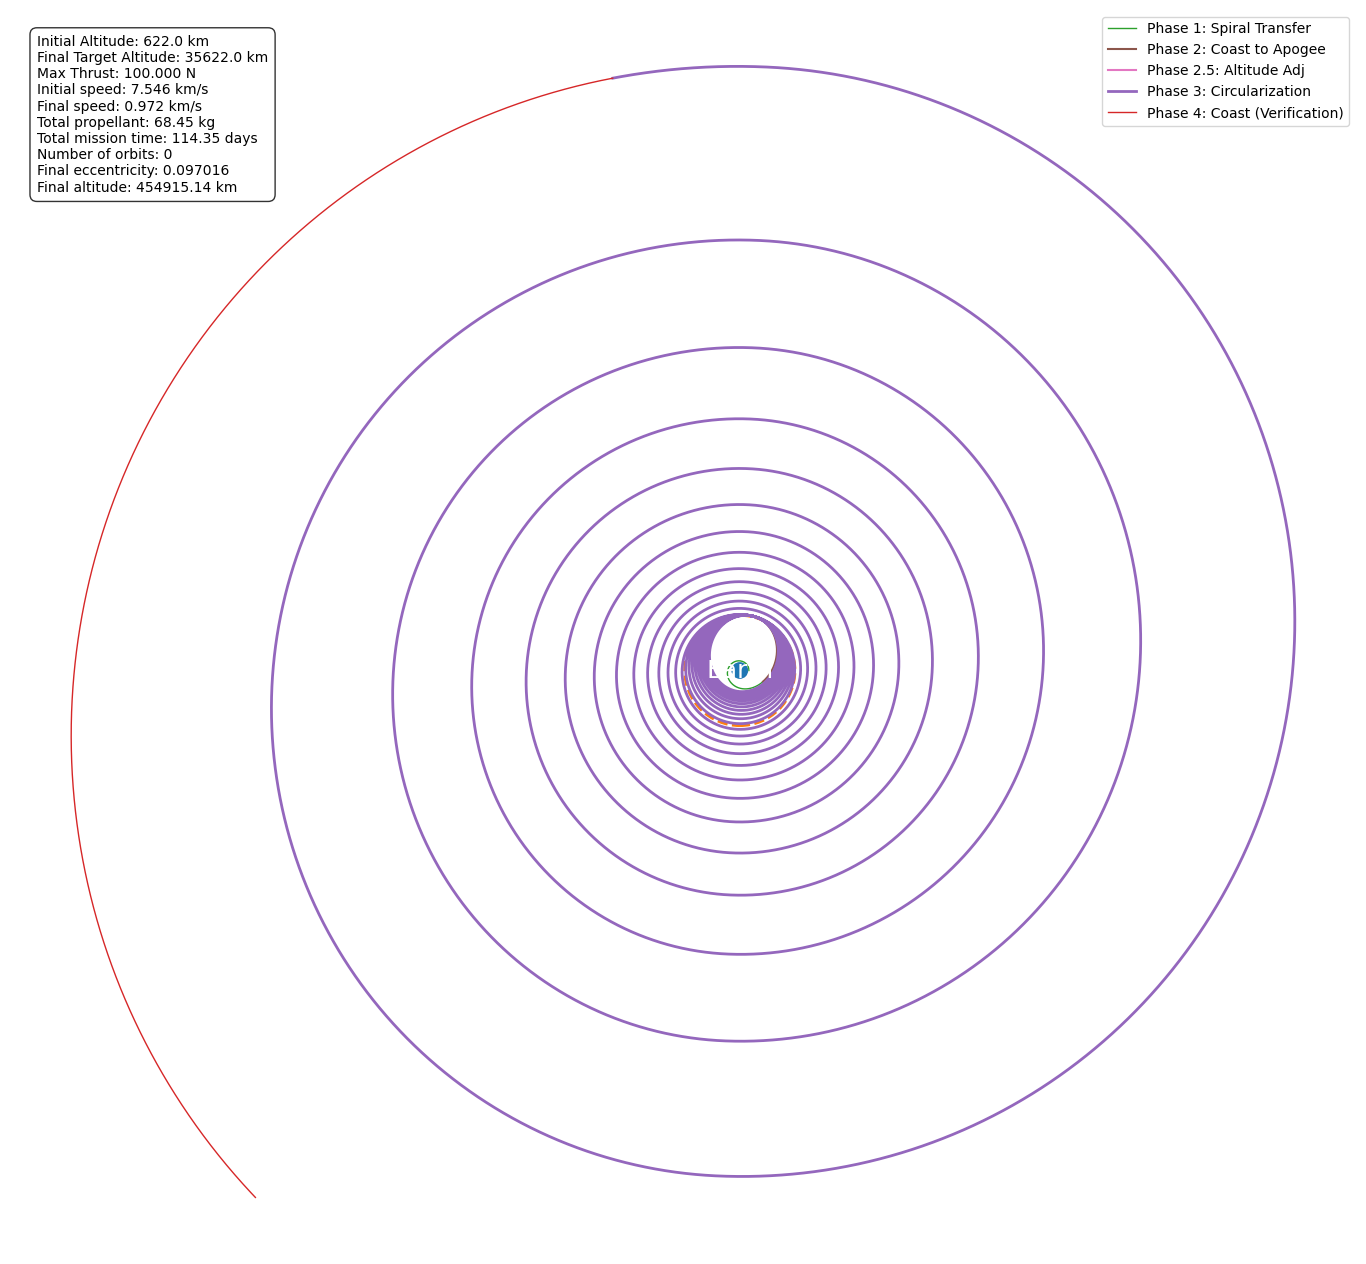

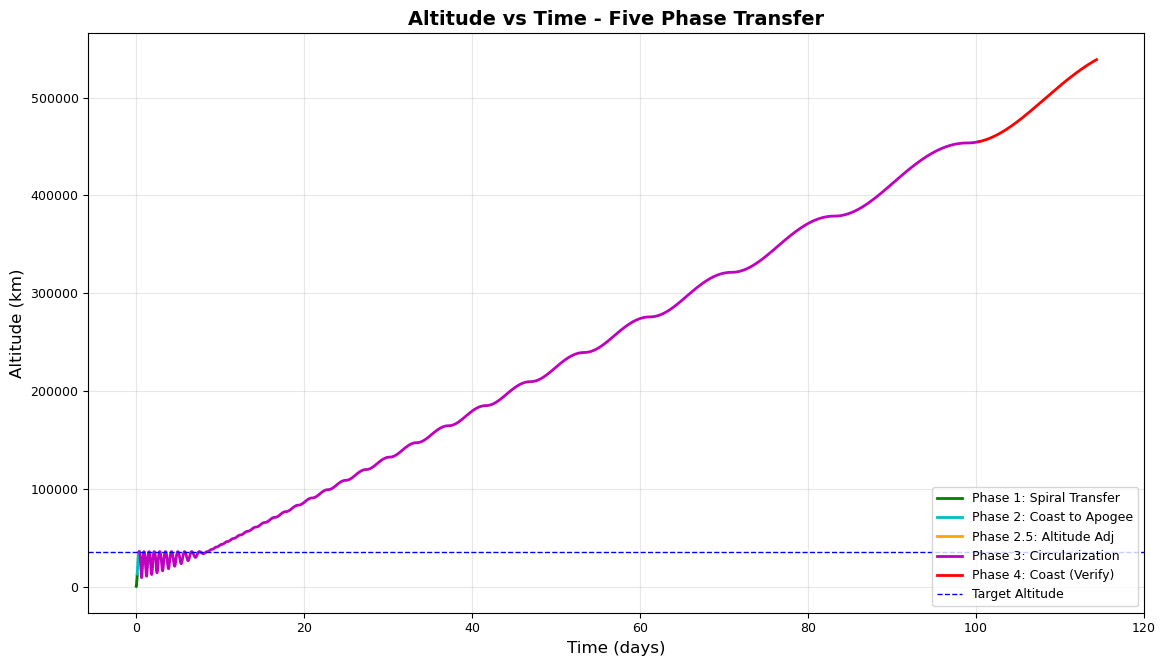

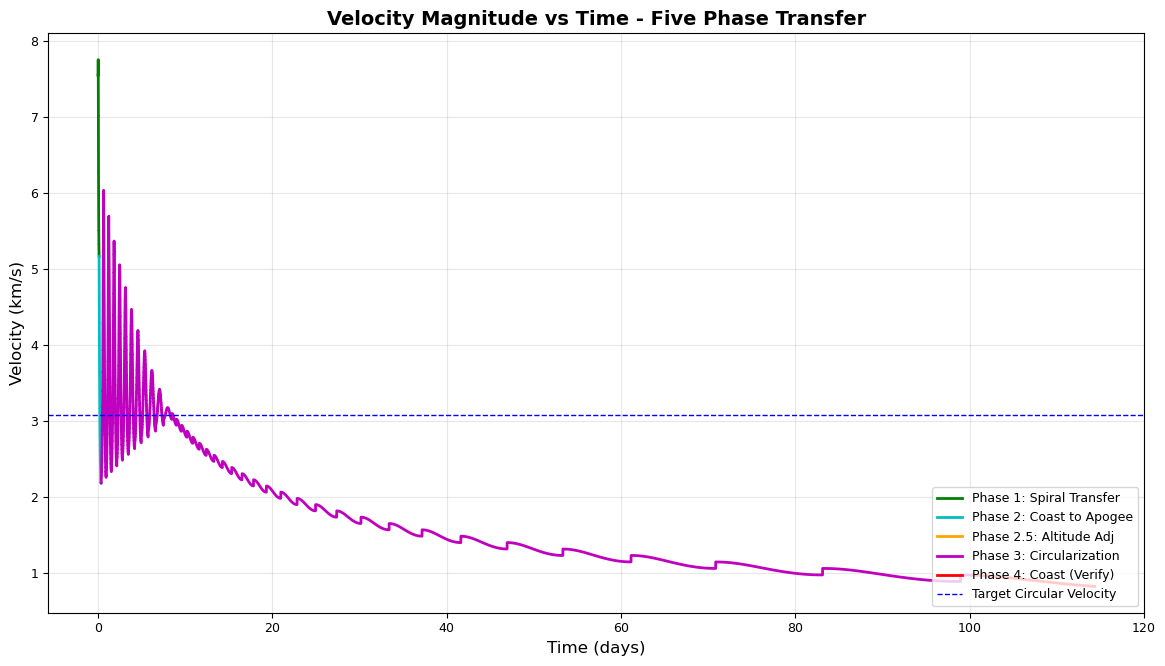

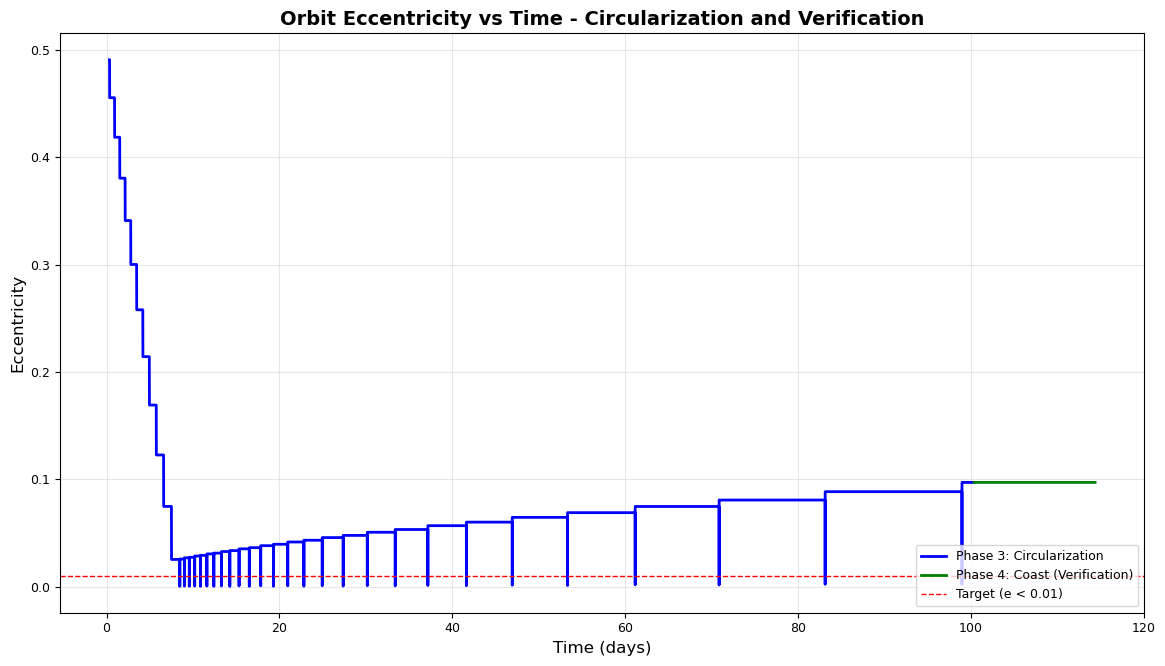

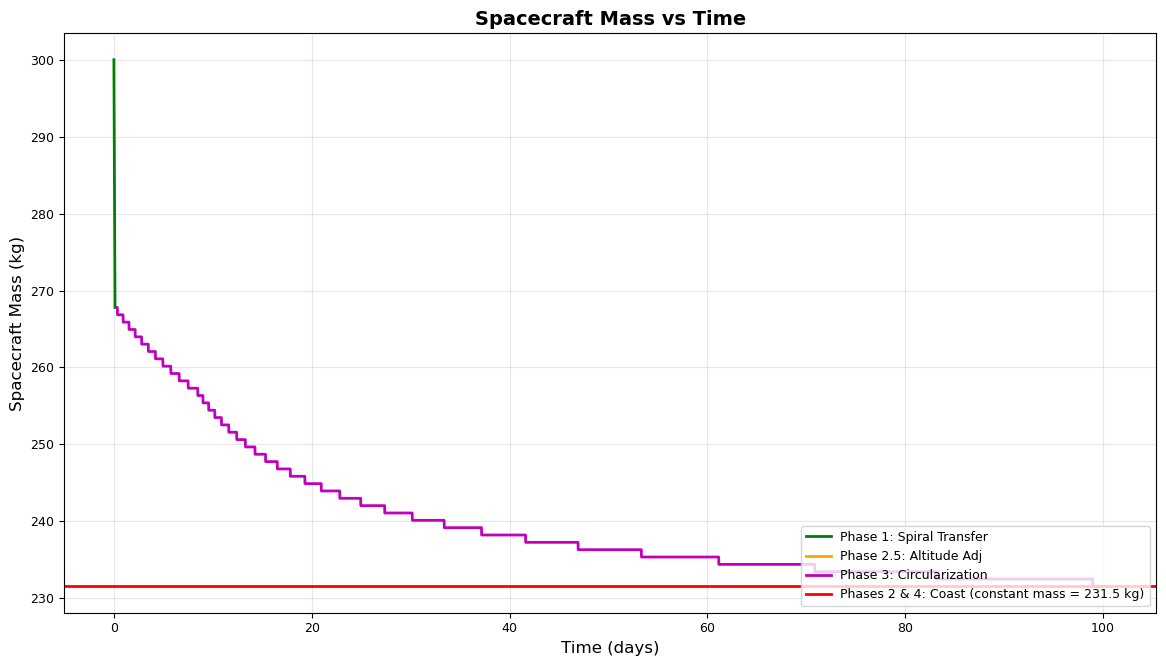

In [4]:
if __name__ == "__main__":
    run(show_plots=True)